In [14]:
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rc
rc("font", family='Malgun Gothic')

In [1]:
import pandas as pd

df = pd.read_excel('0630_텍스트벡터화.xlsx')
df

,별점,내용,내용_토큰,내용_정제,표제어_추출
0,2,Instacart should hold the shoppers more accoun...,"['instacart', 'should', 'hold', 'the', 'shoppe...","['instacart', 'hold', 'shoppers', 'accountable...","['instacart', 'hold', 'shopper', 'accountable'..."
1,1,The delivery times you see before placing your...,"['the', 'delivery', 'times', 'you', 'see', 'be...","['delivery', 'times', 'see', 'placing', 'order...","['delivery', 'time', 'see', 'placing', 'order'..."
2,2,Only order from this app because of the limite...,"['only', 'order', 'from', 'this', 'app', 'beca...","['order', 'app', 'limited', 'options', 'grocer...","['order', 'app', 'limited', 'option', 'grocery..."
3,5,"I love this app. I order my groceries, schedul...","['i', 'love', 'this', 'app', 'i', 'order', 'my...","['love', 'app', 'order', 'groceries', 'schedul...","['love', 'app', 'order', 'grocery', 'schedule'..."
4,5,I love this service and every time I have an i...,"['i', 'love', 'this', 'service', 'and', 'every...","['love', 'service', 'every', 'time', 'issue', ...","['love', 'service', 'every', 'time', 'issue', ..."
...,...,...,...,...,...
2995,2,Their employees dont know how to shop for groc...,"['their', 'employees', 'dont', 'know', 'how', ...","['employees', 'dont', 'know', 'shop', 'groceri...","['employee', 'dont', 'know', 'shop', 'grocery'..."
2996,1,Dont use to order from restaurants. Warning! T...,"['dont', 'use', 'to', 'order', 'from', 'restau...","['dont', 'use', 'order', 'restaurants', 'warni...","['dont', 'use', 'order', 'restaurant', 'warnin..."
2997,1,I had to find out the hard way that they only ...,"['i', 'had', 'to', 'find', 'out', 'the', 'hard...","['find', 'hard', 'way', 'like', 'one', 'shoppe...","['find', 'hard', 'way', 'like', 'one', 'shoppe..."
2998,5,"I have used Instacart for years now, and they ...","['i', 'have', 'used', 'instacart', 'for', 'yea...","['used', 'instacart', 'years', 'always', 'good...","['used', 'instacart', 'year', 'always', 'good'..."


# 워드 임베딩

단어를 밀집 벡터(dense vector)의 형태로 표현하는 방법을 워드 임베딩(word embedding)이라고 합니다.

- 머신러닝 모델은 텍스트를 못 알아먹는다! -> 벡터들로 패턴 학습 시켜야 함
- 단어 간 의미 유사성을 담을 수 있다!

## 1. Word2Vec
주변에 있는 단어로 중심단어를 예측하거나(CBOW) 중심단어로 주변 단어를 예측하는(Skip-Gram) 방법으로 손실 함수를 통해 학습하는 방법

- vector_size = 워드 벡터의 특징 값. 즉, 임베딩 된 벡터의 차원.
- window = 컨텍스트 윈도우 크기
- min_count = 단어 최소 빈도 수 제한 (빈도가 적은 단어들은 학습하지 않는다.)
- workers = 학습을 위한 프로세스 수
- sg = 0은 CBOW, 1은 Skip-gram.
- - 사용자 리뷰처럼 맥락 다양성이 풍부하다면, skip-gram이 더 적합하다고 볼 수 있어요

In [2]:
# 표제어_추출 컬럼을 Word2Vec 입력 형식으로 변환
import ast

# 문자열로 저장된 리스트를 실제 리스트로 변환
df['표제어_추출'] = df['표제어_추출'].apply(ast.literal_eval)

# Word2Vec 학습
from gensim.models import Word2Vec

token_lists = df['표제어_추출'].dropna().tolist()
w2v_model = Word2Vec(sentences=token_lists, vector_size=100, window=5, min_count=2, workers=4, sg=1)

# 예시 단어 'delivery'와 유사한 단어 10개 출력
similar_words = w2v_model.wv.most_similar(positive=['delivery'], topn=10)
similar_words

[('away', 0.8810989260673523),
 ('fast', 0.8734229803085327),
 ('worth', 0.8667946457862854),
 ('including', 0.8491995930671692),
 ('hidden', 0.8486142158508301),
 ('priority', 0.8432785868644714),
 ('attention', 0.840535044670105),
 ('distance', 0.8401070237159729),
 ('person', 0.8368960618972778),
 ('ordering', 0.8356231451034546)]

In [3]:
# 'customer'와 유사한 단어 10개 출력
similar_words = w2v_model.wv.most_similar(positive=['customer'], topn=10)
similar_words

[('terrible', 0.8651639819145203),
 ('poor', 0.8650135397911072),
 ('horrible', 0.8457550406455994),
 ('nothing', 0.8439133763313293),
 ('support', 0.8406076431274414),
 ('worst', 0.8398584723472595),
 ('company', 0.8324020504951477),
 ('chat', 0.8322537541389465),
 ('help', 0.8238550424575806),
 ('ever', 0.8201391696929932)]

In [4]:
# 'item'와 유사한 단어 10개 출력
similar_words = w2v_model.wv.most_similar(positive=['item'], topn=10)
similar_words

[('something', 0.9076030254364014),
 ('substitute', 0.8860307335853577),
 ('replace', 0.8834548592567444),
 ('stock', 0.8825717568397522),
 ('unavailable', 0.878455400466919),
 ('available', 0.876022219657898),
 ('example', 0.8604059815406799),
 ('often', 0.8590027093887329),
 ('listed', 0.8552749752998352),
 ('found', 0.8547806143760681)]

In [5]:
# 'late'와 유사한 단어 10개 출력
similar_words = w2v_model.wv.most_similar(positive=['late'], topn=10)
similar_words

[('pm', 0.9744528532028198),
 ('receive', 0.9671524167060852),
 ('three', 0.9550380110740662),
 ('hr', 0.9538813829421997),
 ('within', 0.9516172409057617),
 ('window', 0.9489884376525879),
 ('waiting', 0.9448486566543579),
 ('arrived', 0.944347620010376),
 ('picked', 0.9437576532363892),
 ('kept', 0.9432553052902222)]

In [6]:
# 'refund'와 유사한 단어 10개 출력
similar_words = w2v_model.wv.most_similar(positive=['refund'], topn=10)
similar_words

[('couldnt', 0.8793357014656067),
 ('refunded', 0.8780155777931213),
 ('refuse', 0.8773748278617859),
 ('refused', 0.8723582625389099),
 ('didnt', 0.8694218993186951),
 ('contacted', 0.85989910364151),
 ('return', 0.8585848212242126),
 ('report', 0.8563897013664246),
 ('claim', 0.8552862405776978),
 ('asked', 0.8528292775154114)]

### 1.1. k-means 클러스터링
PCA, t-SNE으로 유용한 군집 개수 정하기

In [10]:
import numpy as np

# Word2Vec 평균 벡터 계산
def get_average_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

review_vectors = df['표제어_추출'].apply(lambda tokens: get_average_vector(tokens, w2v_model))
X = np.stack(review_vectors.values)

In [20]:
print(X)

[[-0.10384968  0.1501293  -0.06514429 ... -0.20510225  0.1469029
  -0.07629325]
 [-0.08911574  0.07590277  0.00749092 ... -0.21278967  0.19670232
  -0.07231426]
 [-0.1370828   0.16158365 -0.07915083 ... -0.20589633  0.16456981
  -0.05267534]
 ...
 [-0.0592359   0.09440134 -0.0260354  ... -0.21053603  0.13286366
  -0.07615054]
 [-0.08374655  0.10930734 -0.09551968 ... -0.1939191   0.08390852
  -0.09400986]
 [-0.05410016  0.08547325  0.01207113 ... -0.21444681  0.1870266
  -0.10414039]]


C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\anaconda\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\금미\AppData\Local\Temp\ipykernel_11848\2471742125.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


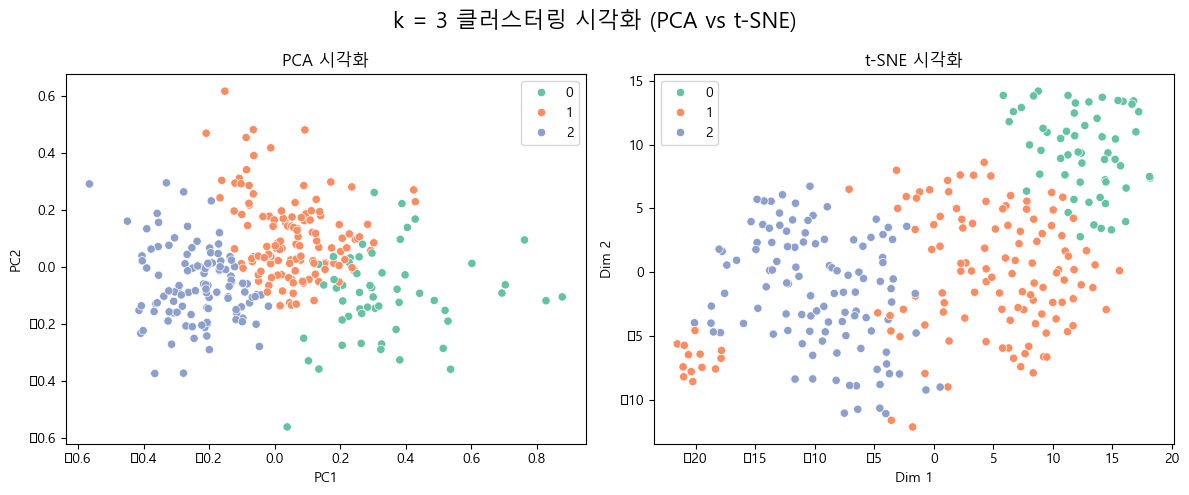

C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\anaconda\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\금미\AppData\Local\Temp\ipykernel_11848\2471742125.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


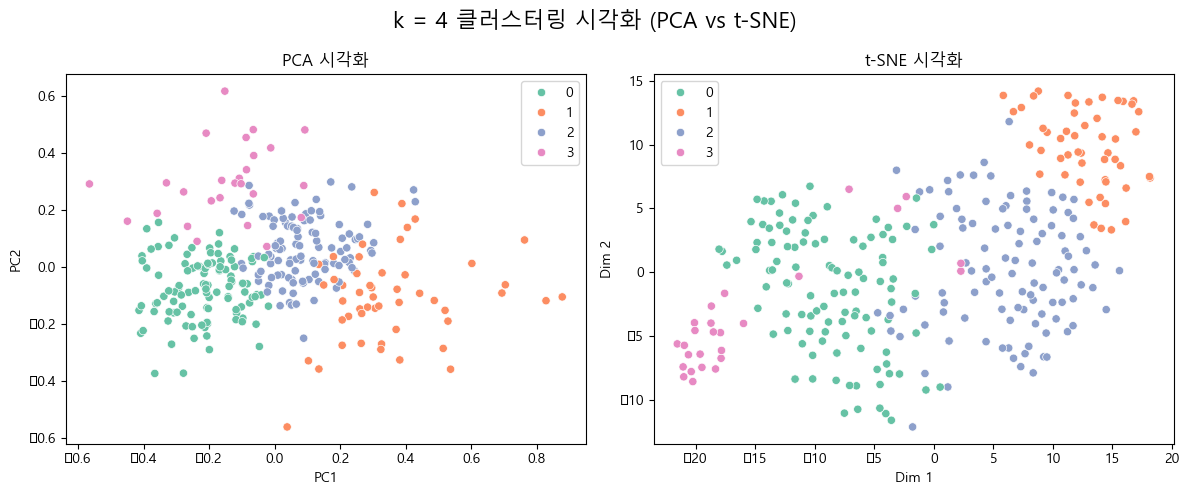

C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\anaconda\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\금미\AppData\Local\Temp\ipykernel_11848\2471742125.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


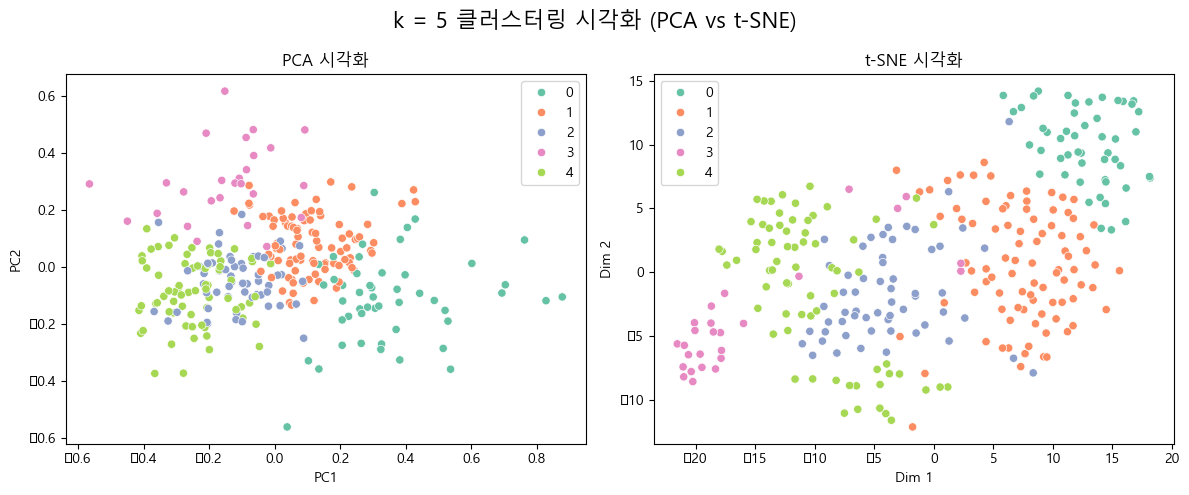

C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\anaconda\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\금미\AppData\Local\Temp\ipykernel_11848\2471742125.py:42: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


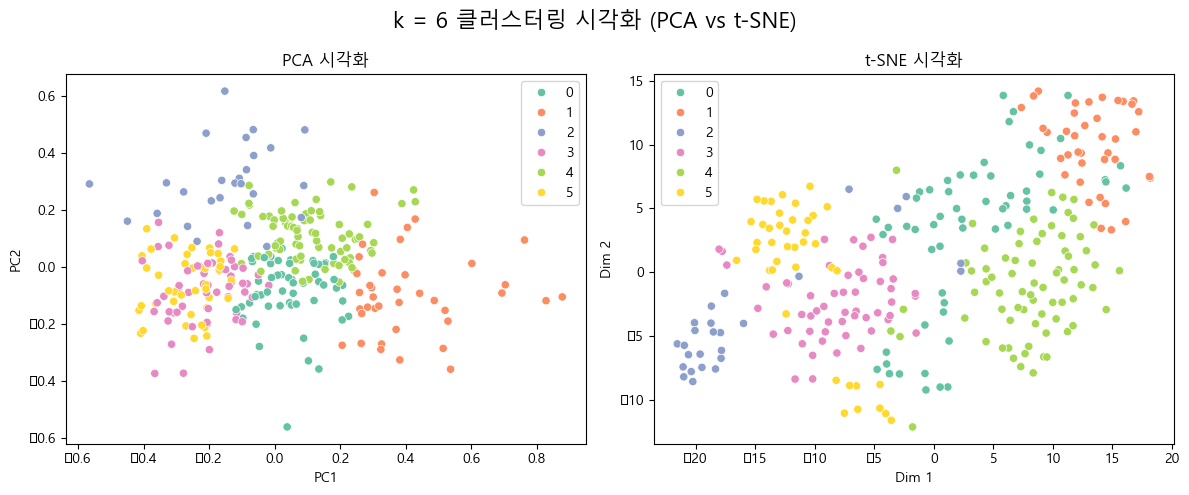

In [15]:
# 랜덤으로 300개 샘플링
sample_df = df.sample(n=300, random_state=42)
sample_tokens = sample_df['표제어_추출']
sample_vectors = sample_tokens.apply(lambda tokens: get_average_vector(tokens, w2v_model))
X_sample = np.stack(sample_vectors.values)

# 시각화용 함수 정의
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

def visualize_clusters(X, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    # PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
    X_tsne = tsne.fit_transform(X)

    # 시각화
    plt.figure(figsize=(12, 5))
    plt.suptitle(f'k = {k} 클러스터링 시각화 (PCA vs t-SNE)', fontsize=16)

    plt.subplot(1, 2, 1)
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2', legend='full')
    plt.title('PCA 시각화')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette='Set2', legend='full')
    plt.title('t-SNE 시각화')
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')

    plt.tight_layout()
    plt.show()

# k = 3, 4, 5, 6에 대해 시각화 실행
for k in [3, 4, 5, 6]:
    visualize_clusters(X_sample, k)

## 2. TF-IDF
-> 별로임 !

## 3. GloVe
Wordvec의 예측 기반 방법과 LSA의 통계(행렬) 기반 방법론을 동시에 사용

- glove.68.zop 을 다운로드하고 압축을 풀어서 glove.6B.100d.txt 파일을 사용해 해당 파일에 있는 사전 훈련된 임베딩 벡터들을 불러온다.
- 40만개 단어 임베딩 벡터가 존재한다. 

In [32]:
import numpy as np

def load_glove_model(glove_file_path):
    glove_dict = {}
    with open(glove_file_path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            glove_dict[word] = vector
    return glove_dict

glove_path = "C:/Users/금미/Desktop/[BDA] 파이썬 프젝/newpj/glove.6B/glove.6B.100d.txt"
glove_model = load_glove_model(glove_path)
print(f"✨ 총 {len(glove_model):,}개의 단어 벡터가 로딩되었습니다.")

✨ 총 400,000개의 단어 벡터가 로딩되었습니다.


In [33]:
def get_review_vector(tokens, model, dim=100):
    vectors = [model[word] for word in tokens if word in model]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(dim)
        
# 표제어_추출 컬럼이 토큰 리스트일 경우
df['glove_vector'] = df['표제어_추출'].apply(lambda tokens: get_review_vector(tokens, glove_model))

X_glove = np.stack(df['glove_vector'].values)
print(X_glove.shape)  # (리뷰 수, 100)

(3000, 100)


In [42]:
print(X_glove)

[[-0.0220736   0.18555593  0.29204255 ... -0.150441    0.3017237
   0.21613866]
 [-0.08035232  0.1034346   0.04415672 ... -0.05878878  0.33072495
   0.04589937]
 [-0.07545239  0.11254945  0.19833915 ... -0.24179377  0.5883491
   0.15968932]
 ...
 [-0.1247022   0.01660442  0.29087886 ... -0.01195718  0.3810213
   0.12869444]
 [ 0.05923977  0.2193919   0.203495   ...  0.01321233  0.49844518
   0.35000655]
 [-0.00491679  0.01601083  0.2124293  ... -0.05427679  0.20500934
   0.23939341]]


### 3.1. k-means 클러스터링
PCA, t-SNE으로 유용한 군집 개수 정하기

C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\금미\AppData\Local\Temp\ipykernel_11848\2860039577.py:20: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


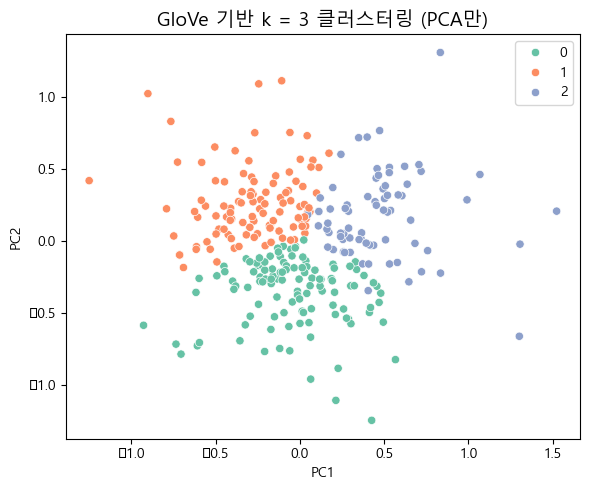

C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\금미\AppData\Local\Temp\ipykernel_11848\2860039577.py:20: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


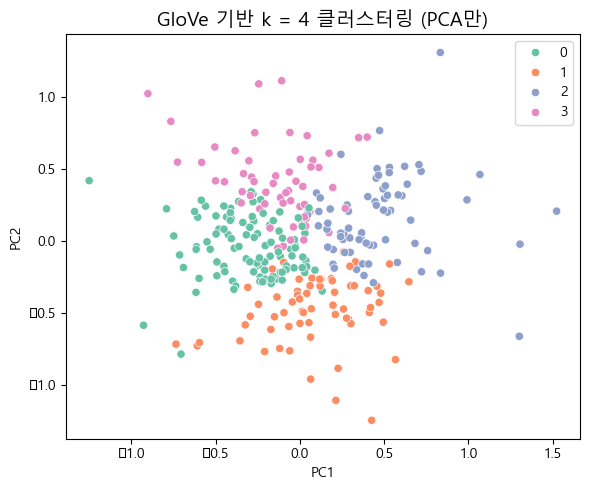

C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\금미\AppData\Local\Temp\ipykernel_11848\2860039577.py:20: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


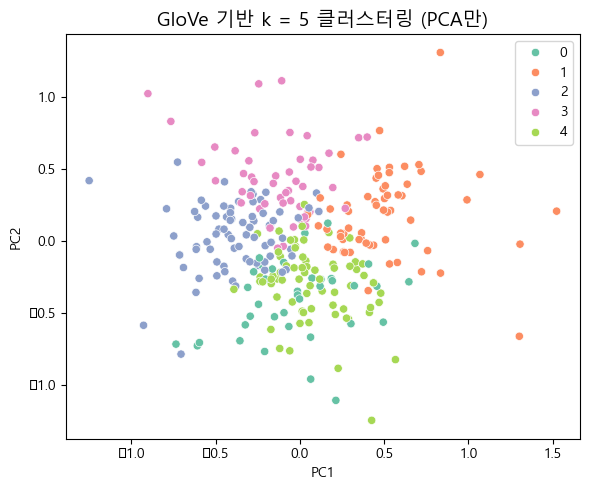

C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\금미\AppData\Local\Temp\ipykernel_11848\2860039577.py:20: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


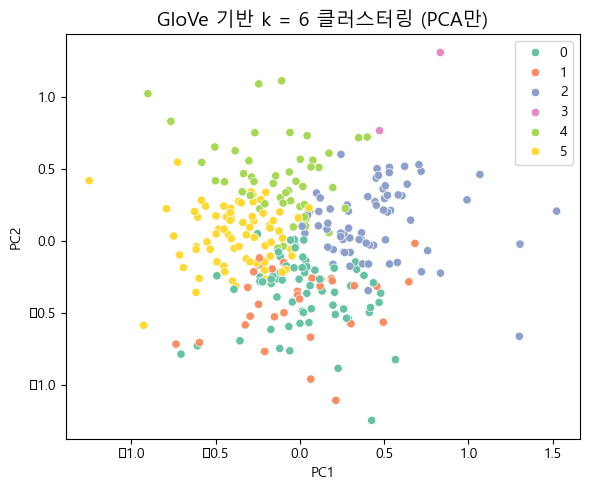

In [43]:
# 랜덤으로 300개 샘플링
sample_df = df.sample(n=300, random_state=42)
X_sample_glove = np.stack(sample_df['glove_vector'].values)

# PCA만 사용하는 클러스터 시각화 함수
def visualize_clusters_pca_only(X, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    # PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)

    # 시각화
    plt.figure(figsize=(6, 5))
    plt.title(f'GloVe 기반 k = {k} 클러스터링 (PCA만)', fontsize=14)
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2', legend='full')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.tight_layout()
    plt.show()

# k = 3, 4, 5, 6에 대해 PCA만 시각화
for k in [3, 4, 5, 6]:
    visualize_clusters_pca_only(X_sample_glove, k)